[ 1.22464680e-22  2.51919410e-07  4.99825925e-07  7.39770571e-07
  9.67931202e-07  1.18067338e-06  1.37460829e-06  1.54664666e-06
  1.69404807e-06  1.81446450e-06  1.90597782e-06  1.96713027e-06
  1.99694776e-06  1.99495529e-06  1.96118462e-06  1.89617369e-06
  1.80095806e-06  1.67705447e-06  1.52643661e-06  1.35150370e-06
  1.15504230e-06  9.40181917e-07  7.10345105e-07  4.69193006e-07
  2.20566998e-07 -3.15724840e-08 -2.83209039e-07 -5.30334277e-07
 -7.69011670e-07 -9.95439259e-07 -1.20601021e-06 -1.39737029e-06
 -1.56647126e-06 -1.71061947e-06 -1.82751874e-06 -1.91530694e-06
 -1.97258568e-06 -1.99844254e-06 -1.99246564e-06 -1.95475020e-06
 -1.88589699e-06 -1.78700279e-06 -1.65964292e-06 -1.50584613e-06
 -1.32806229e-06 -1.12912337e-06 -9.12198318e-07 -6.80742607e-07
 -4.38443154e-07 -1.89159616e-07  6.31370995e-08  3.14428086e-07
  5.60710458e-07  7.98061115e-07  1.02269923e-06  1.23104648e-06
  1.41978404e-06  1.58590547e-06  1.72676455e-06  1.84011751e-06
  1.92415873e-06  1.97754

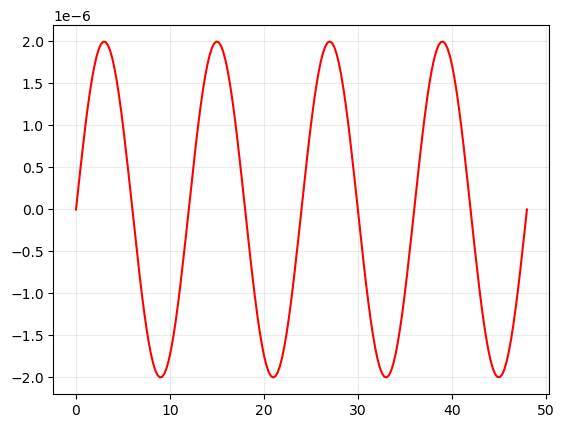

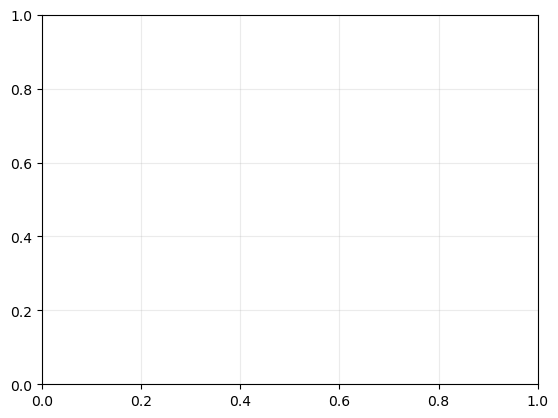

In [25]:
import numpy as np 
import math 
import matplotlib.pyplot as plt

x2 = np.linspace(-10, 0, 100)

x = np.linspace(-0.99, 0.99, 100) 

def create_temperature(x, bottom_temp, top_temp):
    
    y = np.arctanh(x)
    difference = (top_temp - bottom_temp)/4 
    y = difference*y + (top_temp + bottom_temp)/2 
    return y


bottom_temp = 32 
top_temp = 38
# print(y)

t = np.linspace(0, 48*3600, 200)

def get_pressure_at_timestep(time, phase_shift =3):
    Px = np.zeros(200)
    time = time/3600
    T_Px = 12
    period = (2*np.pi)/T_Px
    Px0 = 2e-6
    # Update pressure forcing term for the current timestep
    if T_Px == 0.0:
        Px = Px + Px0 # Steady and constant forcing for now
    else: 
        Px = Px + Px0*np.cos(period * (time - phase_shift)) 
    return Px 


def wind_speed(t, bottom_speed, top_speed, phase_shift = 12):
    hour = t/3600
    period = (2*np.pi)/24
    difference = (top_speed - bottom_speed) #/2
    temp = np.cos(period * (hour - phase_shift))*difference  + (top_speed - difference)
    temp = temp.clip(min=bottom_speed) # During night, light is zero
    return temp

def temperature(t, bottom_temp, top_temp, phase_shift = 12):
    hour = t/3600
    period = (2*np.pi)/24
    difference = (top_temp - bottom_temp) #/2
    temp = np.cos(period * (hour - phase_shift))*difference  + (top_temp - difference)
    temp = temp.clip(min=bottom_temp) # During night, light is zero
    return temp


fig = plt.figure()
ax = plt.gca()
ax.grid(alpha=0.25)
pressure = get_pressure_at_timestep(t, phase_shift = 3)
print(pressure)
# ax.plot(t/3600, temperature(t, bottom_temp, top_temp, phase_shift = 12))
# ax.plot(t/3600, temperature(t, bottom_temp, top_temp, phase_shift = 6))
# ax.plot(t/3600, wind_speed(t, bottom_speed=0, top_speed=5, phase_shift = 6),'-k')
ax.plot(t/3600, pressure,'-r')
fig = plt.figure()
ax = plt.gca()
ax.grid(alpha=0.25)
# temps = np.linspace(32, 34, 10)
# for i,it in enumerate(t):
#     y = create_temperature(x, bottom_temp = bottom_temp, top_temp = temp[i])
#     ax.plot(y, x2)





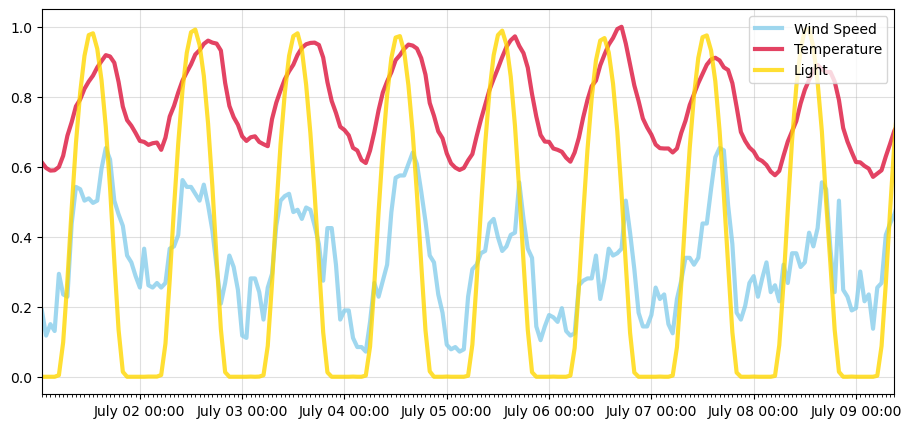

In [45]:

'''
'Stn Id', 'Stn Name', 'CIMIS Region', 'Date', 'Hour (PST)', 'Jul',
       'ETo (in)', 'qc', 'Precip (in)', 'qc.1', 'Sol Rad (Ly/day)', 'qc.2',
       'Vap Pres (mBars)', 'qc.3', 'Air Temp (F)', 'qc.4', 'Rel Hum (%)',
       'qc.5', 'Dew Point (F)', 'qc.6', 'Wind Speed (mph)', 'qc.7',
       'Wind Dir (0-360)', 'qc.8', 'Soil Temp (F)', 'qc.9'
'''
import pandas as pd 

data = pd.read_csv("Holt_CIMIS_data.csv")
times = []
for d,h in zip(data['Date'],data['Hour (PST)']): 
    if "24" in str(h):
        t = pd.to_datetime("%s 2359" % d , format="%m/%d/%Y %H%M") + pd.Timedelta(minutes=1)
    else: 
        
        t = pd.to_datetime("%s %s" % (d,h), format="%m/%d/%Y %H00") 
    times.append(t)
data.index = times 
# data.sort_index(ascending=True)
wind = data["Wind Speed (mph)"]
temp = data["Air Temp (F)"]


# https://www.wcc.nrcs.usda.gov/ftpref/wntsc/H&H/GEM/SolarRadConversion.pdf
data["Sol Rad (Watts/m2)"] = data["Sol Rad (Ly/day)"] *  0.484583 #  1 Langley/day = 0.484583 Watt/m2 
data["Sol Rad (PAR)"] = data["Sol Rad (Watts/m2)"] * 2.02
light = data["Sol Rad (PAR)"] 

# 1 ly/min = 697.3 W/m2


import matplotlib.dates as mdates
# print(time)
# print(times)
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(11,5))
ax = plt.gca()
ax.plot(wind/max(wind), color="skyblue", linewidth= 3, alpha = 0.8, label="Wind Speed")
ax.plot(temp/max(temp),color="crimson", linewidth= 3, alpha = 0.8, label = "Temperature")
ax.plot(light/max(light),color="gold", linewidth= 3, alpha = 0.8, label="Light")
ax.set_xlim(times[0], times[200])
# Format datetime axis
ax.xaxis.set_minor_locator(mdates.HourLocator())
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.grid(alpha=0.4)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %d %H:00'))
plt.show()

# Test


In [46]:
data_out = 0 
data_out = data[["Sol Rad (PAR)"]] 
data_out["Air Temp (C)"] = (data["Air Temp (F)"] - 32) * 5/9
data_out["Wind Speed (m/s)"] = data["Wind Speed (mph)"] * 0.44704

data_out = data_out.dropna()

# Downsample to time step
dt = 10 # seconds
data_out = data_out.resample("10s").interpolate("linear") 
print(data_out )

data_out.to_csv("Holt_CIMIS_data_processed_August2024_10s.csv")

/tmp/ipykernel_578845/2255943195.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out["Air Temp (C)"] = (data["Air Temp (F)"] - 32) * 5/9
/tmp/ipykernel_578845/2255943195.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out["Wind Speed (m/s)"] = data["Wind Speed (mph)"] * 0.44704


                     Sol Rad (PAR)  Air Temp (C)  Wind Speed (m/s)
2024-07-01 01:00:00       0.000000     18.333333          1.296416
2024-07-01 01:00:10       0.000000     18.330710          1.295050
2024-07-01 01:00:20       0.000000     18.328086          1.293684
2024-07-01 01:00:30       0.000000     18.325463          1.292318
2024-07-01 01:00:40       0.000000     18.322840          1.290952
...                            ...           ...               ...
2024-08-30 13:59:20    1654.410836     29.824691          3.978656
2024-08-30 13:59:30    1654.130774     29.826852          3.978656
2024-08-30 13:59:40    1653.850712     29.829012          3.978656
2024-08-30 13:59:50    1653.570650     29.831173          3.978656
2024-08-30 14:00:00    1653.290588     29.833333          3.978656

[523081 rows x 3 columns]
